# Shoe Sell-Through Model — Results

**Model:** Random Forest binary classifier (healthy vs. at-risk)  
**Prediction fires at receipt** — only signals available before any sales are used  
**Evaluated with:** Leave-One-Out Cross-Validation (500 folds)

In [10]:
import pickle
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
from pathlib import Path
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay,
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

DB        = Path("../sellthrough.db")
MODEL_PKL = Path("../models/model.pkl")

HEALTHY_THRESHOLD = 0.45
CAT_FEATURES = ["vendor", "department", "price_tier"]
NUM_FEATURES  = ["avg_retail_price", "receive_month", "units_received"]
FEATURES      = CAT_FEATURES + NUM_FEATURES

CLASS_COLORS = {"healthy": "#2ca02c", "at-risk": "#d62728"}

In [11]:
conn = sqlite3.connect(DB)
df = pd.read_sql_query("SELECT * FROM sku_sell_through", conn)
conn.close()

df["receive_month"] = pd.to_datetime(df["receive_date"]).dt.month
df["label"] = (df["sell_through_rate"] >= HEALTHY_THRESHOLD).astype(int)
df["class"] = df["label"].map({1: "healthy", 0: "at-risk"})

X, y = df[FEATURES], df["label"]

with open(MODEL_PKL, "rb") as f:
    model = pickle.load(f)

print(f"SKUs: {len(df)}  |  healthy: {y.sum()}  |  at-risk: {(y==0).sum()}")

SKUs: 500  |  healthy: 34  |  at-risk: 466


---
## 1. LOO-CV Performance

In [12]:
loo = LeaveOneOut()
y_pred = cross_val_predict(model, X, y, cv=loo)
y_prob = cross_val_predict(model, X, y, cv=loo, method="predict_proba")[:, 1]

print(classification_report(
    y, y_pred,
    target_names=["at-risk", "healthy"],
    zero_division=0,
))
print(f"ROC-AUC : {roc_auc_score(y, y_prob):.3f}")

              precision    recall  f1-score   support

     at-risk       1.00      0.88      0.94       466
     healthy       0.37      0.94      0.53        34

    accuracy                           0.89       500
   macro avg       0.68      0.91      0.73       500
weighted avg       0.95      0.89      0.91       500

ROC-AUC : 0.934


---
## 2. Confusion Matrix

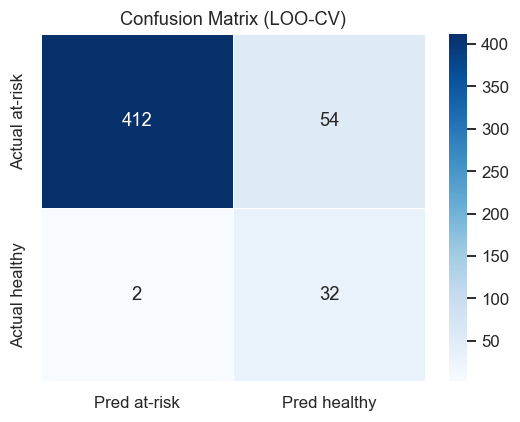

True positives  (healthy caught)   : 32 / 34  (94% recall)
False negatives (healthy missed)   : 2
False positives (at-risk flagged)  : 54
True negatives  (at-risk correct)  : 412


In [13]:
cm = confusion_matrix(y, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    pd.DataFrame(cm,
                 index=["Actual at-risk", "Actual healthy"],
                 columns=["Pred at-risk", "Pred healthy"]),
    annot=True, fmt="d", cmap="Blues", linewidths=0.5, ax=ax,
)
ax.set_title("Confusion Matrix (LOO-CV)")
plt.tight_layout()
plt.show()

print(f"True positives  (healthy caught)   : {tp} / {tp+fn}  ({tp/(tp+fn):.0%} recall)")
print(f"False negatives (healthy missed)   : {fn}")
print(f"False positives (at-risk flagged)  : {fp}")
print(f"True negatives  (at-risk correct)  : {tn}")

---
## 3. ROC & Precision-Recall Curves

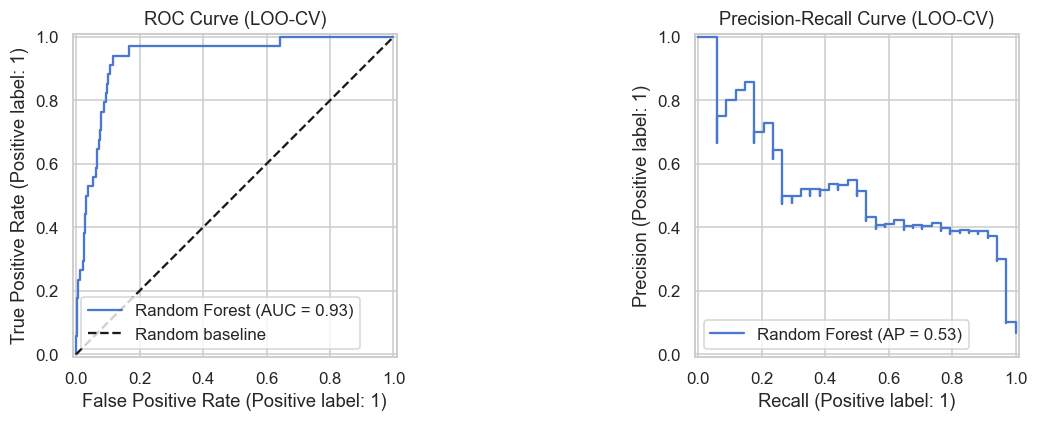

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

RocCurveDisplay.from_predictions(
    y, y_prob, pos_label=1, name="Random Forest", ax=axes[0]
)
axes[0].plot([0, 1], [0, 1], "k--", label="Random baseline")
axes[0].set_title("ROC Curve (LOO-CV)")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y, y_prob, pos_label=1, name="Random Forest", ax=axes[1]
)
axes[1].set_title("Precision-Recall Curve (LOO-CV)")

plt.tight_layout()
plt.show()

---
## 4. Feature Importance

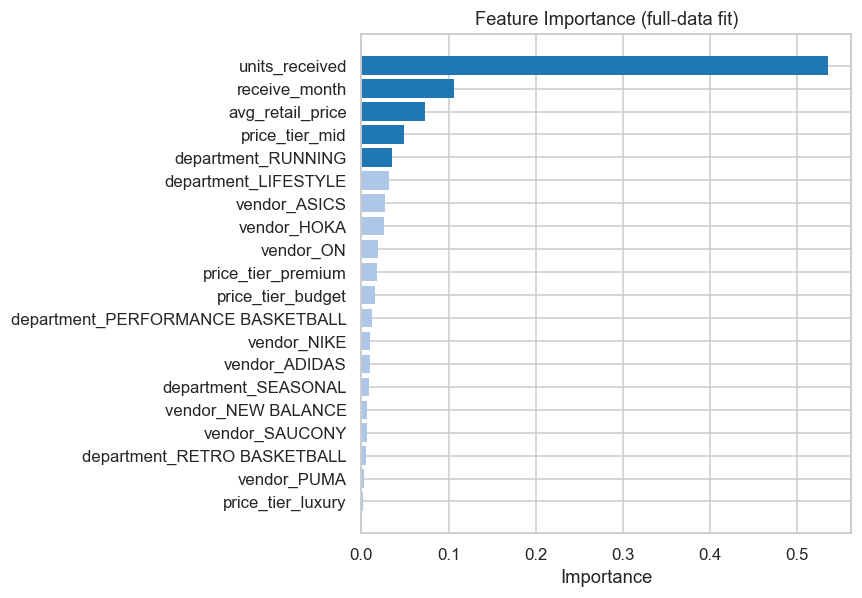

In [15]:
clf = model.named_steps["clf"]
cat_names = (
    model.named_steps["pre"]
         .named_transformers_["cat"]
         .get_feature_names_out(CAT_FEATURES)
)
all_names = list(cat_names) + NUM_FEATURES

imp = (
    pd.DataFrame({"feature": all_names, "importance": clf.feature_importances_})
    .sort_values("importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(8, max(4, len(imp) * 0.28)))
colors = ["#1f77b4" if i >= len(imp) - 5 else "#aec7e8" for i in range(len(imp))]
ax.barh(imp["feature"], imp["importance"], color=colors, edgecolor="none")
ax.set_xlabel("Importance")
ax.set_title("Feature Importance (full-data fit)")
plt.tight_layout()
plt.show()

---
## 5. Predicted Probability Distribution

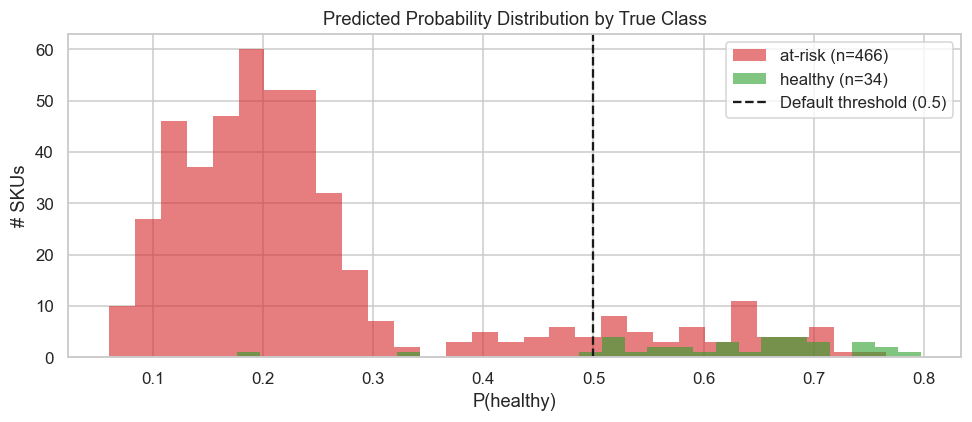

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))

for cls, label, color in [(0, "at-risk", CLASS_COLORS["at-risk"]),
                           (1, "healthy", CLASS_COLORS["healthy"])]:
    mask = y == cls
    ax.hist(y_prob[mask], bins=30, alpha=0.6, label=f"{label} (n={mask.sum()})",
            color=color, edgecolor="none")

ax.axvline(0.5, color="k", linestyle="--", label="Default threshold (0.5)")
ax.set_xlabel("P(healthy)")
ax.set_ylabel("# SKUs")
ax.set_title("Predicted Probability Distribution by True Class")
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Risk Score Table

All SKUs ranked by `P(healthy)`. Use this as the operational output — flag the bottom of the list for markdown or return action before sell window closes.

In [17]:
scores = df[["sku", "brand_desc", "sku_desc", "vendor", "department",
             "price_tier", "avg_retail_price", "sell_through_rate", "class"]].copy()
scores["healthy_prob"] = y_prob.round(3)
scores["predicted"] = pd.Series(y_pred).map({1: "healthy", 0: "at-risk"}).values
scores = scores.sort_values("healthy_prob", ascending=False).reset_index(drop=True)

# Style for display
def highlight_class(row):
    color = "#d4edda" if row["class"] == "healthy" else "#f8d7da"
    return [f"background-color: {color}"] * len(row)

display_cols = ["brand_desc", "sku_desc", "department", "price_tier",
                "sell_through_rate", "class", "predicted", "healthy_prob"]

(
    scores[display_cols]
    .style
    .apply(highlight_class, axis=1)
    .format({"sell_through_rate": "{:.1%}", "healthy_prob": "{:.3f}"})
)

,brand_desc,sku_desc,department,price_tier,sell_through_rate,class,predicted,healthy_prob
0,ON CLOUDMONSTER,CLOUDMONSTER NVY/RED,RUNNING,premium,54.2%,healthy,healthy,0.797
1,ON CLOUD 5,CLOUD 5 YLW/BLK,RUNNING,premium,50.0%,healthy,healthy,0.775
2,NIKE STRUCTURE 25,STRUCTURE 25 OLV/BLK,RUNNING,premium,36.1%,at-risk,healthy,0.766
3,ON CLOUDSURFER,CLOUDSURFER WHT/BLK,RUNNING,premium,52.0%,healthy,healthy,0.759
4,ON CLOUD 5,CLOUD 5 WHT/GLD,RUNNING,premium,50.0%,healthy,healthy,0.750
5,ASICS GEL-KAYANO 31,GEL-KAYANO 31 BLU/GLD,RUNNING,premium,52.0%,healthy,healthy,0.744
6,ON CLOUDMONSTER,CLOUDMONSTER OLV/BLK,RUNNING,premium,50.0%,healthy,healthy,0.741
7,ADIDAS ADIZERO ADIOS 7,ADIZERO ADIOS 7 BRN/GLD,RUNNING,premium,40.6%,at-risk,healthy,0.729
8,ADIDAS SOLAR GLIDE 6,SOLAR GLIDE 6 WHT/BLK,RUNNING,premium,35.1%,at-risk,healthy,0.713
9,NIKE STRUCTURE 25,STRUCTURE 25 ONG/BLK,RUNNING,premium,46.4%,healthy,healthy,0.711


---
## 7. Reorder & Discount Recommendations

Segments derived from `P(healthy)` score:

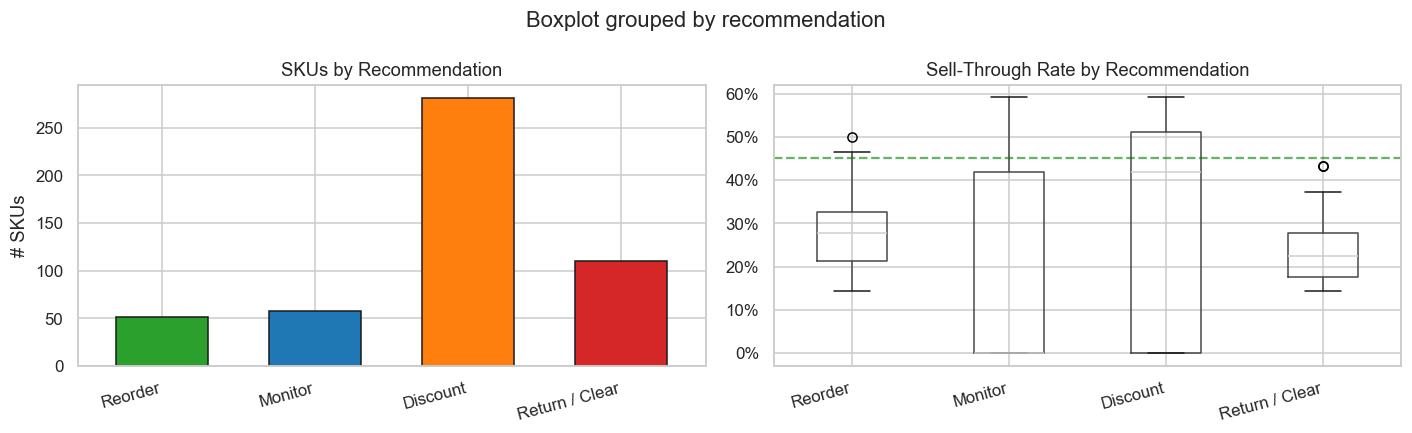

               sell_through_rate               healthy_prob              
                           count   mean median        count   mean median
recommendation                                                           
Reorder                       51  0.335  0.419           51  0.678  0.671
Monitor                       58  0.193  0.000           58  0.502  0.514
Discount                     281  0.269  0.277          281  0.215  0.210
Return / Clear               110  0.238  0.224          110  0.115  0.118


In [18]:
def recommend(p: float) -> str:
    if p >= 0.60:  return "Reorder"
    if p >= 0.35:  return "Monitor"
    if p >= 0.15:  return "Discount"
    return "Return / Clear"

RECOMMENDATION_COLORS = {
    "Reorder":        "#2ca02c",
    "Monitor":        "#1f77b4",
    "Discount":       "#ff7f0e",
    "Return / Clear": "#d62728",
}

scores["recommendation"] = scores["healthy_prob"].apply(recommend)
rec_order = ["Reorder", "Monitor", "Discount", "Return / Clear"]

rec_counts = scores["recommendation"].value_counts().reindex(rec_order).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

rec_counts.plot.bar(
    ax=axes[0],
    color=[RECOMMENDATION_COLORS[r] for r in rec_order],
    edgecolor="k", width=0.6,
)
axes[0].set_title("SKUs by Recommendation")
axes[0].set_xlabel("")
axes[0].set_ylabel("# SKUs")
plt.sca(axes[0])
plt.xticks(rotation=15, ha="right")

# Sell-through distribution within each recommendation bucket
scores.boxplot(
    column="sell_through_rate", by="recommendation",
    positions=range(len(rec_order)),
    ax=axes[1],
)
axes[1].set_xticklabels(rec_order, rotation=15, ha="right")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].axhline(HEALTHY_THRESHOLD, color="green", linestyle="--", alpha=0.6)
axes[1].set_title("Sell-Through Rate by Recommendation")
axes[1].set_xlabel("")
plt.sca(axes[1])
plt.title("Sell-Through Rate by Recommendation")

plt.tight_layout()
plt.show()

print(scores.groupby("recommendation")[["sell_through_rate", "healthy_prob"]]
       .agg(["count", "mean", "median"])
       .reindex(rec_order)
       .round(3)
       .to_string())

---
## 8. Model Summary

| Metric | Value |
|---|---|
| Algorithm | Random Forest (200 trees, max_depth=3, class_weight=balanced) |
| Evaluation | Leave-One-Out CV (500 folds) |
| Healthy recall | 94% (32 / 34 caught) |
| Healthy precision | 37% |
| ROC-AUC | 0.934 |
| Top feature | units_received (54%) |

**Recall is the primary metric.** Missing a healthy SKU means a missed reorder — the cost of a false negative exceeds the cost of a false positive in this domain.

**Limitations:**
- Trained on synthetic data — performance on real retail data will vary
- `units_received` dominance (54%) suggests buyer confidence is the strongest at-receipt signal; real data may surface additional features (launch type, historical brand performance, channel)
- Threshold of 0.45 for healthy/at-risk should be validated against business markdown windows when real data is available